# 13 · Memory — *extra pattern*

Agents forget everything between calls unless you give them memory. LangGraph has two kinds:

| Kind | Scope | Mechanism |
|---|---|---|
| **Short-term** | one conversation (`thread_id`) | the **checkpointer** saves the message history |
| **Long-term** | across conversations, per user | a **Store** (key-value with namespaces) you read/write yourself |

We use `qwen3:0.6b` to extract facts worth remembering and `llama3.1` to chat.

In [6]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

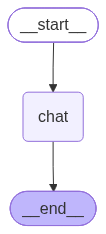

In [7]:
import uuid
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver        # short-term (per thread)
from langgraph.store.memory import InMemoryStore             # long-term (per user) - use a DB-backed store in prod
from langgraph.store.base import BaseStore

def chat(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    """LangGraph injects `config` and `store` automatically if the function asks for them by name."""
    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id)                         # memories are grouped per user

    # 1) READ long-term memory and put it into the system prompt
    known = [item.value["fact"] for item in store.search(namespace)]
    system = SystemMessage("You are a friendly assistant. Facts you know about the user:\n"
                           + ("\n".join(f"- {f}" for f in known) or "- (nothing yet)"))
    reply = llm.invoke([system] + state["messages"])

    # 2) WRITE: let the tiny model pull out a durable fact from the latest user message
    last_user = state["messages"][-1].content
    fact = small_llm.invoke(
        "If the message states a personal fact (name, city, job, preference), rewrite it as ONE short sentence. "
        f"Otherwise reply exactly NONE.\nMessage: {last_user}"
    ).content.strip()
    if fact.upper() != "NONE" and len(fact) < 200:
        store.put(namespace, str(uuid.uuid4()), {"fact": fact})
        print("💾 remembered:", fact)

    return {"messages": [reply]}

builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

store = InMemoryStore()
graph = builder.compile(checkpointer=InMemorySaver(), store=store)
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

### Short-term memory: same `thread_id` → remembers the conversation

In [8]:
t1 = {"configurable": {"thread_id": "chat-1", "user_id": "asha"}}
graph.invoke({"messages": [("user", "Hi! I'm Asha and I live in Cuttack.")]}, t1)
r = graph.invoke({"messages": [("user", "What did I just tell you my name was?")]}, t1)
print("🤖", r["messages"][-1].content)

💾 remembered: Hi! I'm Asha and live in Cuttack.
💾 remembered: ONE short sentence: "I just told you my name was a city in the heart of the mountains."
🤖 You told me your name is Asha, and you live in Cuttack.


### Long-term memory: **new** thread, same `user_id` → still knows her

In [9]:
t2 = {"configurable": {"thread_id": "chat-2-brand-new", "user_id": "asha"}}   # fresh conversation!
r = graph.invoke({"messages": [("user", "Where do I live?")]}, t2)
print("🤖", r["messages"][-1].content)

print("\nStore contents:", [i.value["fact"] for i in store.search(("memories", "asha"))])

💾 remembered: NONE.
🤖 You live in Cuttack!

Store contents: ["Hi! I'm Asha and live in Cuttack.", 'ONE short sentence: "I just told you my name was a city in the heart of the mountains."', 'NONE.']


**Other user** → no leakage, because the namespace differs:

In [10]:
t3 = {"configurable": {"thread_id": "chat-3", "user_id": "ravi"}}
print("🤖", graph.invoke({"messages": [("user", "Where do I live?")]}, t3)["messages"][-1].content)

💾 remembered: NONE.
🤖 I don't have any information about your location yet. Would you like to share where you live? I'm here to help and can provide information about your area if you'd like.
